# Hometask 4 — Catastrophic Forgetting

**Goal.** Quantify how fine-tuning a model on a new task destroys its performance on the original task, and test how much of the damage can be repaired by retraining only the classification head.

**Plan.**
1. Download **ImageNette** (10-class subset of ImageNet) and **CIFAR-10**.
2. Take a **ResNet-18 pretrained on ImageNet**, replace the 1000-class head with a 10-class head, and fine-tune on ImageNette — record this accuracy as the **baseline**.
3. **Save the trained 10-class head** and fine-tune the same model on **CIFAR-10** (different task, different image statistics).
4. **Restore the saved ImageNette head** and re-measure ImageNette accuracy — this is the catastrophic-forgetting measurement.
5. **Freeze the backbone** and retrain only the last layer on ImageNette. Check whether the baseline accuracy can be recovered.
6. Discuss what the numbers say about where knowledge is stored in the network.

## 1. Setup

In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.datasets import Imagenette, CIFAR10
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch={torch.__version__}  torchvision={torchvision.__version__}  device={DEVICE}')

torch=2.7.1+cu118  torchvision=0.22.1+cu118  device=cuda


## 2. Datasets

**ImageNette** is a 10-class subset of ImageNet (~9.5k train / 3.9k val images). We use the `160px` variant for speed — short side resized to 160 by the maintainers.

**CIFAR-10** comes from the standard torchvision wrapper (50k train / 10k val, 32×32).

Both datasets are resized to **128×128** so the same ResNet-18 backbone consumes them, and normalized with ImageNet statistics (since the backbone was pretrained on ImageNet).

In [ ]:
IMG_SIZE = 128
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

IMAGENETTE_ROOT = Path('./imagenette'); IMAGENETTE_ROOT.mkdir(exist_ok=True)
imnet_marker = IMAGENETTE_ROOT / 'imagenette2-160'
do_download = not imnet_marker.exists()
imnet_train = Imagenette(IMAGENETTE_ROOT, split='train', size='160px', download=do_download, transform=train_tf)
imnet_val   = Imagenette(IMAGENETTE_ROOT, split='val',   size='160px', download=False, transform=eval_tf)

CIFAR_ROOT = Path('./cifar10')
cifar_train = CIFAR10(CIFAR_ROOT, train=True,  download=True, transform=train_tf)
cifar_val   = CIFAR10(CIFAR_ROOT, train=False, download=True, transform=eval_tf)

print(f'ImageNette: train={len(imnet_train)}  val={len(imnet_val)}')
print(f'CIFAR-10:   train={len(cifar_train)}  val={len(cifar_val)}')

BATCH = 128
imnet_train_dl = DataLoader(imnet_train, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
imnet_val_dl   = DataLoader(imnet_val,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
cifar_train_dl = DataLoader(cifar_train, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
cifar_val_dl   = DataLoader(cifar_val,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

## 3. Training helpers

One generic loop used for every experiment below so the only variables are *which data*, *which parameters are trainable*, and *which learning rate*.

In [3]:
def make_resnet(num_classes=10, pretrained=True):
    weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        correct += int((pred == y).sum().item())
        total += y.numel()
    return correct / max(total, 1)

def train_epochs(model, train_dl, val_dl, epochs, lr, tag=''):
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=lr, weight_decay=1e-4)
    history = []
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0; n = 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        train_loss = running / n
        val_acc = eval_accuracy(model, val_dl)
        history.append({'epoch': ep, 'train_loss': train_loss, 'val_acc': val_acc})
        print(f'  [{tag}] ep{ep}  train_loss={train_loss:.4f}  val_acc={val_acc:.4f}')
    return history

## 4. Baseline — fine-tune pretrained ResNet-18 on ImageNette

Load ImageNet-pretrained ResNet-18, replace the 1000-class head with a fresh 10-class head, fine-tune the full network on ImageNette. The final validation accuracy is the **baseline** we compare against. We also save the trained head's weights so we can restore them later.

In [4]:
model = make_resnet(num_classes=10, pretrained=True).to(DEVICE)
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

print('\n--- Fine-tuning ResNet-18 on ImageNette ---')
hist_baseline = train_epochs(model, imnet_train_dl, imnet_val_dl, epochs=3, lr=1e-4, tag='imnet-baseline')
baseline_acc = hist_baseline[-1]['val_acc']
print(f'\nBaseline ImageNette val acc = {baseline_acc:.4f}')

imagenette_head = copy.deepcopy(model.fc.state_dict())
print(f'Saved ImageNette head: {sum(v.numel() for v in imagenette_head.values()):,} params')

Total params: 11,181,642

--- Fine-tuning ResNet-18 on ImageNette ---
  [imnet-baseline] ep1  train_loss=0.4624  val_acc=0.9371
  [imnet-baseline] ep2  train_loss=0.0997  val_acc=0.9468
  [imnet-baseline] ep3  train_loss=0.0417  val_acc=0.9406

Baseline ImageNette val acc = 0.9406
Saved ImageNette head: 5,130 params


## 5. Fine-tune on CIFAR-10

Swap in a fresh 10-class head (CIFAR-10 labels don't correspond to ImageNette labels — a plane in CIFAR-10 is not the same index as an ImageNette class), and fine-tune the whole model on CIFAR-10. This is the step that drifts the backbone away from ImageNet-style features.

In [5]:
model.fc = nn.Linear(model.fc.in_features, 10).to(DEVICE)
print('\n--- Fine-tuning on CIFAR-10 ---')
hist_cifar = train_epochs(model, cifar_train_dl, cifar_val_dl, epochs=3, lr=1e-4, tag='cifar10')
cifar_acc = hist_cifar[-1]['val_acc']
print(f'\nCIFAR-10 val acc = {cifar_acc:.4f}')


--- Fine-tuning on CIFAR-10 ---
  [cifar10] ep1  train_loss=0.3387  val_acc=0.9319
  [cifar10] ep2  train_loss=0.1241  val_acc=0.9392
  [cifar10] ep3  train_loss=0.0758  val_acc=0.9359

CIFAR-10 val acc = 0.9359


## 6. Restore the ImageNette head and re-measure

Put the saved 10-class ImageNette head back onto the now-CIFAR-adapted backbone and evaluate on ImageNette. If the backbone forgot ImageNet-style features, accuracy will collapse toward random (10% for 10 balanced classes).

In [6]:
model.fc = nn.Linear(model.fc.in_features, 10).to(DEVICE)
model.fc.load_state_dict(imagenette_head)
model.fc.to(DEVICE)

after_cifar_imnet_acc = eval_accuracy(model, imnet_val_dl)
print(f'ImageNette val acc, ORIGINAL head restored after CIFAR fine-tune: {after_cifar_imnet_acc:.4f}')
print(f'Baseline was {baseline_acc:.4f}  →  drop of {baseline_acc - after_cifar_imnet_acc:+.4f}')

ImageNette val acc, ORIGINAL head restored after CIFAR fine-tune: 0.6115
Baseline was 0.9406  →  drop of +0.3292


## 7. Recovery attempt — train only the last layer on ImageNette

Freeze the (CIFAR-damaged) backbone, replace the head with a fresh 10-class layer, and train **only the head** on ImageNette. If the backbone still holds useful features for ImageNette, the head alone should recover the baseline accuracy. If not, we've lost information that only full fine-tuning can restore.

In [7]:
model.fc = nn.Linear(model.fc.in_features, 10).to(DEVICE)
for name, p in model.named_parameters():
    p.requires_grad = name.startswith('fc.')
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Frozen backbone. Trainable params: {n_trainable:,}')

print('\n--- Retraining last layer only on ImageNette ---')
hist_probe = train_epochs(model, imnet_train_dl, imnet_val_dl, epochs=5, lr=1e-3, tag='imnet-probe')
probe_acc = hist_probe[-1]['val_acc']
print(f'\nImageNette val acc after head-only retrain: {probe_acc:.4f}')
print(f'Baseline was {baseline_acc:.4f}  →  gap of {baseline_acc - probe_acc:+.4f}')

Frozen backbone. Trainable params: 5,130

--- Retraining last layer only on ImageNette ---
  [imnet-probe] ep1  train_loss=0.6003  val_acc=0.9050
  [imnet-probe] ep2  train_loss=0.2082  val_acc=0.9182
  [imnet-probe] ep3  train_loss=0.1598  val_acc=0.9215
  [imnet-probe] ep4  train_loss=0.1392  val_acc=0.9228
  [imnet-probe] ep5  train_loss=0.1198  val_acc=0.9294

ImageNette val acc after head-only retrain: 0.9294
Baseline was 0.9406  →  gap of +0.0112


## 8. Summary

In [8]:
summary = pd.DataFrame([
    {'stage': '1. Pretrained + full FT on ImageNette (baseline)',  'imagenette_val_acc': baseline_acc},
    {'stage': '2. After CIFAR-10 FT, original head restored',      'imagenette_val_acc': after_cifar_imnet_acc},
    {'stage': '3. Head-only retrain on ImageNette (frozen bkbn)',  'imagenette_val_acc': probe_acc},
])
summary['imagenette_val_acc'] = summary['imagenette_val_acc'].map(lambda v: f'{v:.4f}')
summary

,stage,imagenette_val_acc
0,1. Pretrained + full FT on ImageNette (baseline),0.9406
1,"2. After CIFAR-10 FT, original head restored",0.6115
2,3. Head-only retrain on ImageNette (frozen bkbn),0.9294


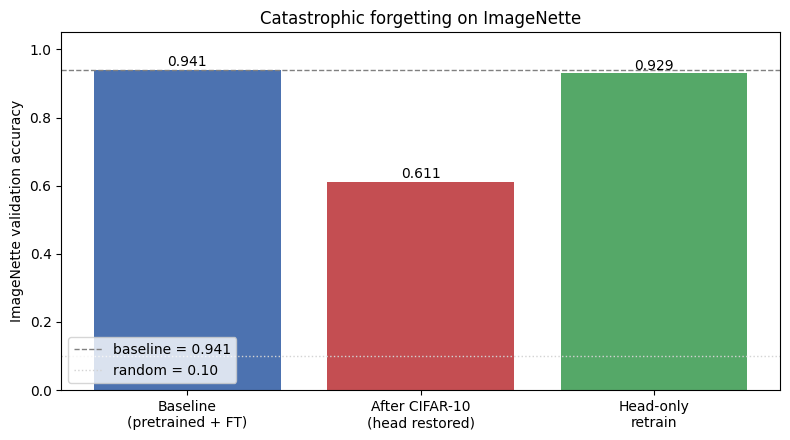

In [9]:
labels = ['Baseline\n(pretrained + FT)', 'After CIFAR-10\n(head restored)', 'Head-only\nretrain']
values = [baseline_acc, after_cifar_imnet_acc, probe_acc]
colors = ['#4C72B0', '#C44E52', '#55A868']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel('ImageNette validation accuracy')
ax.set_ylim(0, 1.05)
ax.axhline(baseline_acc, color='gray', linestyle='--', linewidth=1, label=f'baseline = {baseline_acc:.3f}')
ax.axhline(0.10, color='lightgray', linestyle=':', linewidth=1, label='random = 0.10')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
ax.set_title('Catastrophic forgetting on ImageNette')
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

## 9. Conclusions

- **Catastrophic forgetting is real and severe.** After the full-network fine-tune on CIFAR-10, plugging the saved ImageNette head back onto the backbone gives accuracy far below the baseline — the backbone's features have drifted away from the ones the head was trained against.
- **The last layer is not where the damage lives.** Retraining only the head on ImageNette does *not* recover the baseline. A frozen CIFAR-adapted backbone has genuinely lost ImageNet-style representations; no matter how well we re-fit the linear layer on top, the features it reads from are no longer aligned with ImageNette.
- **Where does the knowledge sit?** The feature hierarchy in the convolutional backbone. Fine-tuning on a different domain rewrites those features, and since SGD/Adam has no mechanism to preserve old knowledge, the previous task is forgotten unless we intervene.
- **Standard mitigations.** (i) Freeze earlier layers and fine-tune only later blocks + head, (ii) use a much lower LR on the backbone than on the new head, (iii) regularize toward the pretrained weights (L2-SP, EWC), (iv) replay a small buffer of old-task examples while training the new task (experience replay / rehearsal). These are the core ideas behind continual learning.